In [1]:
import torch
import torchvision
from torch import nn
from torchvision import transforms

from d2l import torch as d2l
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
class BaseData:
    def __init__(self, root='../data/'):
        self.root = root

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(True)

    def val_dataloader(self):
        return self.get_dataloader(False)

class FashionMNIST(BaseData):
    def __init__(self, root='../data/', batch_size=64, resize=(28, 28), num_workers=2):
        super().__init__(root)
        
        self.batch_size = batch_size
        self.num_workers = num_workers

        transform = transforms.Compose([
            transforms.Resize(resize),
            transforms.ToTensor()
        ])

        self.train = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=True,
            download=True,
            transform=transform
        )

        self.val = torchvision.datasets.FashionMNIST(
            root=self.root,
            train=False,
            download=True,
            transform=transform
        )

    def text_labels(self, indices):
        labels = [
            't-shirt', 'trouser', 'pullover', 'dress', 'coat',
            'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
        ]

        return [labels[int(i)] for i in indices]

    def get_dataloader(self, train):
        data = self.train if train else self.val

        return torch.utils.data.DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=train,
            num_workers=self.num_workers
        )
    
    def visualize(self, batch, nrows=1, ncols=8, labels=None):
        X, y = batch
        if labels is None:
            labels = self.text_labels(y)
        d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)

In [3]:
class Classifier:
    def __init__(self, model):
        self.model = model

    def __call__(self, X):
        return self.forward(X)

    def parameters(self):
        raise NotImplementedError

    def forward(self, X):
        raise NotImplementedError

    def loss(self, y_hat, y):
        raise NotImplementedError

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), self.lr)

    def accuracy(self, y_hat, y, averaged=True):
        preds = torch.argmax(y_hat, 1)
        compare = (preds == y).type(torch.float32)

        return compare.mean() if averaged else compare

    def training_step(self, batch):
        y = batch[-1]
        y_hat = self(*batch[:-1])

        return self.loss(y_hat, y)

    def validation_step(self, batch):
        y = batch[-1]
        y_hat = self(*batch[:-1])

        return self.loss(y_hat, y), self.accuracy(y_hat, y)

class SoftmaxClassifierScratch(Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__(self)
        
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.lr = lr

        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)
    
    def parameters(self):
        return [self.W, self.b]

    def softmax(self, X):
        X = X - X.amax(1, keepdim=True)
        X_exp = torch.exp(X)
        partition = torch.sum(X_exp, 1, keepdim=True)
        
        return X_exp / partition
    
    def forward(self, X):
        X = X.reshape((X.shape[0], -1))
        
        return self.softmax((X @ self.W) + self.b)

    def loss(self, y_hat, y):
        return -torch.log(
            y_hat[torch.arange(len(y_hat)), y]
        ).mean()

In [4]:
class Trainer:
    def __init__(self, max_epochs):
        self.max_epochs = max_epochs
        
        self.train_dataloader = None
        self.val_dataloader = None
        self.num_train_batches = None
        self.num_val_batches = None

        self.model = None
        self.optim = None

        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0

        self.train_losses = []
        self.val_losses = []
        
        self.val_accs = []

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        
        self.val_dataloader = data.val_dataloader()
        self.num_val_batches = (
            len(self.val_dataloader)
            if self.val_dataloader
            else 0
        )

    def prepare_model(self, model):
        model.trainer = self
        self.model = model

    def prepare_batch(self, batch):
        return batch

    def fit_epoch(self):
        train_loss = 0.0
    
        for batch in self.train_dataloader:
            loss = self.model.training_step(
                self.prepare_batch(batch)
            )
    
            self.optim.zero_grad()
            loss.backward()
    
            with torch.no_grad():
                self.optim.step()
    
            train_loss += loss.item()
            self.train_batch_idx += 1
    
        train_loss /= len(self.train_dataloader)
        self.train_losses.append(train_loss)
    
        if not self.val_dataloader:
            self.plot()
            
            print(
                f'Epoch {self.epoch + 1}/{self.max_epochs} '
                f'| train_loss: {train_loss:.6f}'
            )
            return
    
        val_loss = 0.0
        val_acc = 0.0
    
        with torch.no_grad():
            for batch in self.val_dataloader:
                loss, acc = self.model.validation_step(
                    self.prepare_batch(batch)
                )
    
                val_loss += loss.item()
                val_acc += acc.item()
                
                self.val_batch_idx += 1
    
        val_loss /= len(self.val_dataloader)
        self.val_losses.append(val_loss)

        val_acc /= len(self.val_dataloader)
        self.val_accs.append(val_acc)

        self.plot()
    
        print(
            f'Epoch {self.epoch + 1}/{self.max_epochs} '
            f'| train_loss: {train_loss:.6f} '
            f'| val_loss: {val_loss:.6f} '
            f'| val_acc: {val_acc:.6f}'
        )

    def plot(self):
        clear_output(wait=True)
        
        plt.figure(figsize=(7, 4))
        plt.plot(self.train_losses, label='Train loss')
        plt.plot(self.val_losses, label='Validation loss')
        plt.plot(self.val_accs, label='Validation accuracy')
        
        plt.xlabel('Epoch')
        plt.ylabel('Metric')
        plt.legend()
        plt.grid(True)
        plt.show()

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        
        self.optim = model.configure_optimizers()

        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0

        self.train_losses = []
        self.val_losses = []

        self.val_accs = []

        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

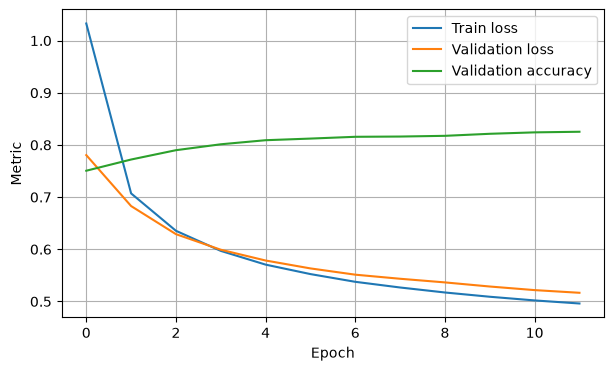

Epoch 12/12 | train_loss: 0.496078 | val_loss: 0.516608 | val_acc: 0.825293


In [5]:
data = FashionMNIST(batch_size=256)

model = SoftmaxClassifierScratch(num_inputs=784, num_outputs=10, lr=0.03)

trainer = Trainer(max_epochs=12)
trainer.fit(model, data)

In [6]:
X, y = next(iter(data.val_dataloader()))

with torch.no_grad():
    y_hat = model(X)

In [7]:
preds = y_hat.argmax(1)

wrong = preds != y

wrong.type(torch.int).sum() / len(preds)

tensor(0.1562)

In [8]:
right = preds == y

right.type(torch.int).sum() / len(preds)

tensor(0.8438)

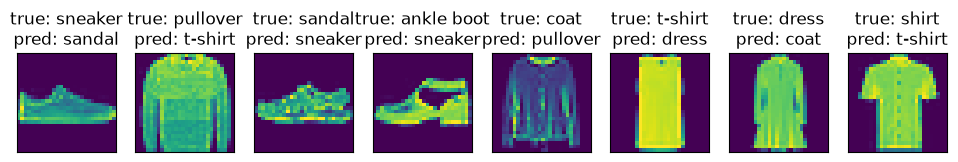

In [9]:
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [
    f'true: {a}\npred: {b}'
    for a,b in zip(data.text_labels(y), data.text_labels(preds))
]

data.visualize([X, y], labels=labels)

In [10]:
class SoftmaxClassifier(Classifier):
    def __init__(self, num_outputs, lr, sigma=0.01):
        linear = nn.LazyLinear(num_outputs)

        linear.weight.data.normal_(0, sigma)
        linear.bias.data.fill_(0)
        
        model = nn.Sequential(
            nn.Flatten(),
            linear
        )
        
        super().__init__(model)

        self.num_outputs = num_outputs
        self.lr = lr

    def parameters(self):
        return self.model.parameters()

    def forward(self, X):
        return self.model(X)

    def loss(self, Y_hat, Y, averaged=True):
        # reshaped to support multi-dimensional predictions & targets
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        Y = Y.reshape((-1))
        
        return nn.functional.cross_entropy(
            Y_hat, Y, reduction='mean' if averaged else 'none'
        )

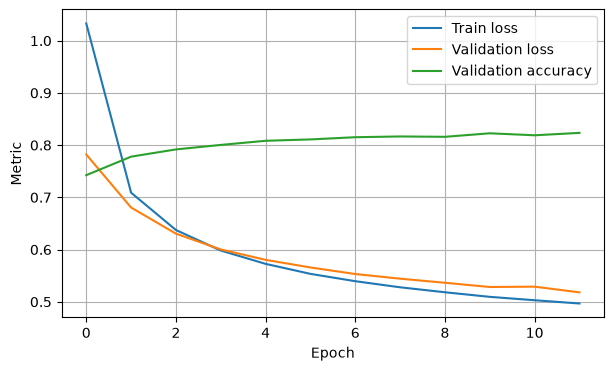

Epoch 12/12 | train_loss: 0.496746 | val_loss: 0.518080 | val_acc: 0.823438


In [11]:
model = SoftmaxClassifier(num_outputs=10, lr=0.03)

trainer = Trainer(max_epochs=12)
trainer.fit(model, data)

In [12]:
X, y = next(iter(data.val_dataloader()))

with torch.no_grad():
    y_hat = model(X)

In [13]:
preds = y_hat.argmax(1)

wrong = preds != y

wrong.type(torch.int).sum() / len(preds)

tensor(0.1602)

In [14]:
right = preds == y

right.type(torch.int).sum() / len(preds)

tensor(0.8398)

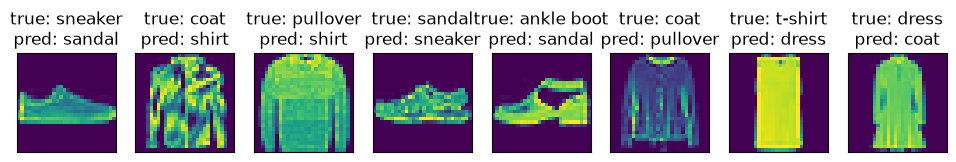

In [15]:
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [
    f'true: {a}\npred: {b}'
    for a,b in zip(data.text_labels(y), data.text_labels(preds))
]

data.visualize([X, y], labels=labels)